## Dependency Installation

In [1]:
! pip install pypots==v0.18


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
import pypots
import os


In [3]:
import pandas as pd
import numpy as np
import logging
from types import SimpleNamespace

# simple logger (to keep your logger.info line working)
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger("preprocess")

# mimic argparse args with your two paths
args = SimpleNamespace(
    ground_truth_path=r"C:\Users\vikto\Documents\SAITS\bcer_data\application_tasks_ground_truth_new_database.txt",
    missing_data_path=r"C:\Users\vikto\Documents\SAITS\bcer_data\application_tasks_missing_new_database.txt",
)


In [4]:
# Load datasets
df_ground = pd.read_csv(args.ground_truth_path)
df_missing = pd.read_csv(args.missing_data_path)
# Print number of samples
num_samples_ground = len(df_ground)
logger.info(f"Total samples in ground truth: {num_samples_ground}")

# Print missing value counts
missing_in_ground = df_ground["STARTED_DURATION"].isna().sum()
missing_in_missing = df_missing["STARTED_DURATION"].isna().sum()
print(f"Missing STARTED_DURATION in ground truth: {missing_in_ground}")
print(f"Missing STARTED_DURATION in missing data file: {missing_in_missing}")


INFO:preprocess:Total samples in ground truth: 73073


Missing STARTED_DURATION in ground truth: 18297
Missing STARTED_DURATION in missing data file: 25596


In [ ]:
# Merge ground truth and missing data
df_missing['STARTED_DURATION_ground'] = df_ground['STARTED_DURATION']
# Remove MISSING_FLAG column
df_missing.drop(columns=['MISSING_FLAG'], inplace=True, errors='ignore')
# Sort values by APPLICATION_ID and LATEST_DATE_hours
df_missing.sort_values(by=['APPLICATION_ID', 'LATEST_DATE_hours'], inplace=True)
# Set index to APPLICATION_ID and APPLICATION_TASK_ID
df_missing.set_index(['APPLICATION_ID', 'APPLICATION_TASK_ID'], inplace=True)


In [7]:
exclude_features = [
    "APPLICATION_NUMBER","TASK_NAME", "USER_ID", "APPLICATION_TYPE_CODE", "PROPONENT", "SUBMITTED_DATE_hours",
    "ASSIGN_DATE_hours", "ASSIGN_DURATION", "MEDIAN_CREATED_DURATION", "MEDIAN_ASSIGN_DURATION", "APPLICATION_STATUS_CODE",
    "MEDIAN_FIRST_ASSIGN_DURATION", "DETERMINATION_DATE_hours", "FIRST_ASSIGN_hours"
]
df_missing['APPLICATION_STATUS_CODE2'] = df_missing['APPLICATION_STATUS_CODE'].apply(
    lambda x: 1 if x in [0, 2] else 0
)
df_missing.drop(columns=exclude_features, inplace=True, errors='ignore')
df_missing

REVISION_NUMBER  TASK_ITERATION  \
APPLICATION_ID APPLICATION_TASK_ID                                    
340030         340104                             0               0   
               343010                             0               0   
               340103                             0               0   
               443152                             0               0   
               443173                             0               0   
...                                             ...             ...   
13018893       13020863                           2               2   
               13020862                           2               2   
               13020861                           2               2   
               13029763                           2               0   
               13033600                           2               0   

                                    USER_TASK_STATUS  FIRST_ASSIGN_DURATION  \
APPLICATION_ID APPLICATION_TASK_ID                                            
340030         340104                              0               4.566667   
               343010                              0              72.250000   
               340103                              0             845.683333   
               443152                              0               1.233333   
               443173                              0               0.050000   
...                                              ...                    ...   
13018893       13020863                            0               0.116667   
               13020862                            0              49.250000   
               13020861                            0              49.633333   
               13029763                            0               2.416667   
               13033600                            0               0.350000   

                                    CREATED_DURATION  STARTED_DURATION  \
APPLICATION_ID APPLICATION_TASK_ID                                       
340030         340104                      26.466667          4.553056   
               343010                      72.650000         72.243333   
               340103                     964.516667        387.646944   
               443152                       1.666667          1.213611   
               443173                      90.233333          0.034722   
...                                              ...               ...   
13018893       13020863                     0.350000          0.009444   
               13020862                    52.000000               NaN   
               13020861                    52.383333               NaN   
               13029763                     2.416667          2.403611   
               13033600                     0.483333          0.318333   

                                    TASK_HISTORY_STATUS_CHANGES  \
APPLICATION_ID APPLICATION_TASK_ID                                
340030         340104                                         4   
               343010                                         4   
               340103                                         6   
               443152                                         4   
               443173                                         4   
...                                                         ...   
13018893       13020863                                       4   
               13020862                                       5   
               13020861                                       5   
               13029763                                       4   
               13033600                                       4   

                                    HALT_DURATION  APPLICATION_DURATION  \
APPLICATION_ID APPLICATION_TASK_ID                                        
340030         340104                         0.0             46.454861   
               343010   

In [8]:
binary_columns = ["HIGH_RISK_IND", "MAJOR_PROJECT_IND", "PRIORITY_CODE", "USER_TASK_STATUS", "APPLICATION_STATUS_CODE2"]

no_log_transform_features = [
    "REVISION_NUMBER", "TASK_ITERATION", "TASK_HISTORY_STATUS_CHANGES", "TASK_COUNT",
    "OPEN_APPLICATIONS", "OPEN_TASKS", "TOTAL_ACTIVITY_COUNT", "WAITING_TIME", "APPLICATION_DURATION"
]
df_missing[binary_columns] = df_missing[binary_columns].replace(2, 0)
df_missing[binary_columns] = df_missing[binary_columns].astype(int)


In [9]:
# Define feature columns, excluding categorical features and ground truth
feature_columns = [
    col for col in df_missing.columns
    if col not in exclude_features + binary_columns + ['STARTED_DURATION_ground']
]

log_transform_features = [
    col for col in feature_columns
    if col not in no_log_transform_features + binary_columns + ['STARTED_DURATION_ground']
]
log_transform_features

['FIRST_ASSIGN_DURATION',
 'CREATED_DURATION',
 'STARTED_DURATION',
 'HALT_DURATION',
 'CREATED_DATE_hours',
 'LATEST_DATE_hours']

In [10]:
# Check for negative values in features that will be log-transformed
negative_features = df_missing[log_transform_features].lt(0).any()
negative_columns = negative_features[negative_features].index.tolist()

negative_started_duration_indices = df_missing[df_missing['CREATED_DURATION'] < 0].index.tolist()

print(f"Found {len(negative_started_duration_indices)} rows with negative STARTED_DURATION.")
print(negative_started_duration_indices)


Found 0 rows with negative STARTED_DURATION.
[]


In [11]:
df_missing.loc[df_missing['FIRST_ASSIGN_DURATION'] < 0, 'FIRST_ASSIGN_DURATION'] = df_missing['CREATED_DURATION']
df_missing.loc[df_missing['STARTED_DURATION'] < 0, 'STARTED_DURATION'] = df_missing['FIRST_ASSIGN_DURATION']
df_missing.loc[df_missing['STARTED_DURATION_ground'] < 0, 'STARTED_DURATION_ground'] = df_missing['FIRST_ASSIGN_DURATION']

In [12]:
# === snapshot a fully independent copy BEFORE scaling ===
df_before_scaling = df_missing.copy(deep=True)


In [13]:
df_before_scaling

REVISION_NUMBER  TASK_ITERATION  \
APPLICATION_ID APPLICATION_TASK_ID                                    
340030         340104                             0               0   
               343010                             0               0   
               340103                             0               0   
               443152                             0               0   
               443173                             0               0   
...                                             ...             ...   
13018893       13020863                           2               2   
               13020862                           2               2   
               13020861                           2               2   
               13029763                           2               0   
               13033600                           2               0   

                                    USER_TASK_STATUS  FIRST_ASSIGN_DURATION  \
APPLICATION_ID APPLICATION_TASK_ID                                            
340030         340104                              0               4.566667   
               343010                              0              72.250000   
               340103                              0             845.683333   
               443152                              0               1.233333   
               443173                              0               0.050000   
...                                              ...                    ...   
13018893       13020863                            0               0.116667   
               13020862                            0              49.250000   
               13020861                            0              49.633333   
               13029763                            0               2.416667   
               13033600                            0               0.350000   

                                    CREATED_DURATION  STARTED_DURATION  \
APPLICATION_ID APPLICATION_TASK_ID                                       
340030         340104                      26.466667          4.553056   
               343010                      72.650000         72.243333   
               340103                     964.516667        387.646944   
               443152                       1.666667          1.213611   
               443173                      90.233333          0.034722   
...                                              ...               ...   
13018893       13020863                     0.350000          0.009444   
               13020862                    52.000000               NaN   
               13020861                    52.383333               NaN   
               13029763                     2.416667          2.403611   
               13033600                     0.483333          0.318333   

                                    TASK_HISTORY_STATUS_CHANGES  \
APPLICATION_ID APPLICATION_TASK_ID                                
340030         340104                                         4   
               343010                                         4   
               340103                                         6   
               443152                                         4   
               443173                                         4   
...                                                         ...   
13018893       13020863                                       4   
               13020862                                       5   
               13020861                                       5   
               13029763                                       4   
               13033600                                       4   

                                    HALT_DURATION  APPLICATION_DURATION  \
APPLICATION_ID APPLICATION_TASK_ID                                        
340030         340104                         0.0             46.454861   
               343010   

In [14]:
# Apply log1p transformation (log(x+1))
df_missing[log_transform_features] = np.log1p(df_missing[log_transform_features])
df_missing[['STARTED_DURATION_ground']] = np.log1p(df_missing[['STARTED_DURATION_ground']])


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Fit the main scaler on feature columns
scaler = StandardScaler()
df_missing[feature_columns] = scaler.fit_transform(df_missing[feature_columns])

# Identify the correct index of STARTED_DURATION in feature_columns
duration_index = feature_columns.index("STARTED_DURATION")

# Extract mean and std of STARTED_DURATION from the fitted scaler
duration_mean = scaler.mean_[duration_index]
duration_std  = scaler.scale_[duration_index]

# Standardize STARTED_DURATION_ground using the same mean and std
df_missing['STARTED_DURATION_ground'] = (df_missing['STARTED_DURATION_ground'] - duration_mean) / duration_std


In [16]:
# Group by application ID before normalization and train-test split
application_ids = df_missing.index.get_level_values('APPLICATION_ID').unique()

# 70% train, 30% val+test
train_ids, val_test_ids = train_test_split(application_ids, test_size=0.3, random_state=42)

# split val_test_ids into ~65% val (20% overall), ~35% test (10% overall)
val_ids, test_ids = train_test_split(val_test_ids, test_size=0.35, random_state=42)

# Build splits
train_data = df_missing.loc[df_missing.index.get_level_values('APPLICATION_ID').isin(train_ids)].copy()
val_data   = df_missing.loc[df_missing.index.get_level_values('APPLICATION_ID').isin(val_ids)].copy()
test_data = df_missing.loc[df_missing.index.get_level_values('APPLICATION_ID').isin(test_ids)].copy()
# Use the full dataset to get imputation for all values less than 1 hour 
full_data  = df_missing.copy()


In [35]:
def group_and_pad_by_application(data, max_seq_length):
    """
    Build fixed-length, per-application sequences with padding and masks.

    Inputs
    ------
    data : pandas.DataFrame
        Index must be MultiIndex with levels ('APPLICATION_ID', 'APPLICATION_TASK_ID').
        Columns include:
          - feature columns used for modeling (already scaled/transformed),
          - 'STARTED_DURATION'          : the (possibly missing) feature in the missing-view,
          - 'STARTED_DURATION_ground'   : the aligned ground-truth column for STARTED_DURATION.

    max_seq_length : int
        The target length for each application's sequence. Shorter sequences are padded to this length.

    Returns
    -------
    tuple of np.ndarray:
        sequences         : (N_apps, max_seq_length, D)    # X (with STARTED_DURATION replaced by ground truth)
        X_hats            : (N_apps, max_seq_length, D)    # X_hat (missing-view with NaNs where missing)
        original_ids      : (N_apps, max_seq_length)       # APPLICATION_TASK_IDs (−1 for padded positions)
        missing_masks     : (N_apps, max_seq_length, D)    # 1 where X_hat is observed, 0 where NaN
        indicating_masks  : (N_apps, max_seq_length, D)    # 1 where X differs from X_hat (i.e., masked positions), else 0
        padding_masks     : (N_apps, max_seq_length)       # 1 for real timesteps, 0 for padding
    """
    # Group rows by application; each group's rows are the time-ordered tasks of that application
    grouped = data.groupby(level='APPLICATION_ID')

    # Containers to accumulate per-application outputs
    sequences = []         # X : features with STARTED_DURATION replaced by ground truth
    original_ids = []      # task IDs (for traceability)
    X_hats = []            # X_hat : features from the "missing" view (contains NaNs)
    missing_masks = []     # mask of observed positions in X_hat (1=observed, 0=NaN)
    indicating_masks = []  # mask of artificially missing positions (1=difference between X and X_hat)
    padding_masks = []     # mask over timesteps (1=real step, 0=padding)

    # Feature dimension D: all columns except the ground-truth helper column
    feature_size = data.shape[1] - 1  # Excluding 'STARTED_DURATION_ground'

    for app_id, group in grouped:
        # X_hat is the "missing-view" feature matrix (NaNs indicate missing values)
        X_hat = group.drop(columns=['STARTED_DURATION_ground']).to_numpy()

        # X is the "ground-truth-replaced" version:
        # overwrite STARTED_DURATION with its ground truth, then drop helper column
        group = group.copy()
        group['STARTED_DURATION'] = group['STARTED_DURATION_ground']  # put GT into feature column
        X = group.drop(columns=['STARTED_DURATION_ground']).to_numpy()

        # Keep original task IDs (for traceability through padding)
        task_ids = group.index.get_level_values('APPLICATION_TASK_ID').to_numpy()

        # Masks over features:
        # missing_mask: 1 where X_hat has an observed value, 0 where it's NaN (i.e., originally missing)
        missing_mask = (~np.isnan(X_hat)).astype(np.float32)

        # indicating_mask: 1 where X and X_hat differ in missingness pattern
        # Here it marks the positions that were missing in X_hat but are present in X (i.e., imputable/ground-truth-filled)
        indicating_mask = ((~np.isnan(X_hat)) ^ (~np.isnan(X))).astype(np.float32)

        # Allocate padded arrays for this application (timesteps = max_seq_length)
        # All zeros by default; we will copy the real timesteps at the front
        X_padded               = np.full((max_seq_length, feature_size), np.nan, dtype=np.float32)
        X_hat_padded           = np.full((max_seq_length, feature_size), np.nan, dtype=np.float32)
        missing_mask_padded    = np.zeros((max_seq_length, feature_size), dtype=np.float32)
        indicating_mask_padded = np.zeros((max_seq_length, feature_size), dtype=np.float32)
        original_ids_padded    = np.full((max_seq_length,), -1, dtype=np.int32)

        # Actual length (number of tasks) for this application
        seq_len = len(group)

        # padding_mask marks which timesteps correspond to real data (1) vs padding (0)
        padding_mask = np.zeros((max_seq_length,), dtype=np.float32)
        padding_mask[:seq_len] = 1.0  # the first seq_len steps are real

        # Copy the real (un-padded) portion into the front of each padded array
        X_padded[:seq_len, :]               = X
        X_hat_padded[:seq_len, :]           = X_hat
        missing_mask_padded[:seq_len, :]    = missing_mask
        indicating_mask_padded[:seq_len, :] = indicating_mask
        original_ids_padded[:seq_len]       = task_ids

        # Accumulate for this application
        sequences.append(X_padded)
        X_hats.append(X_hat_padded)
        missing_masks.append(missing_mask_padded)
        indicating_masks.append(indicating_mask_padded)
        original_ids.append(original_ids_padded)
        padding_masks.append(padding_mask)

    # Stack lists into arrays with shape (N_apps, ...)
    return (np.array(sequences),
            np.array(X_hats),
            np.array(original_ids),
            np.array(missing_masks),
            np.array(indicating_masks),
            np.array(padding_masks))


In [36]:
# Determine the maximum sequence length across applications.
# Every per-app sequence will be padded to this length so that tensors have uniform shapes.
max_seq_length = max(len(group) for _, group in df_missing.groupby(level='APPLICATION_ID'))
print("seq_len :", max_seq_length)

# Build tensors for each split.
# Each call returns:
#   X                : (N_apps, T=max_seq_length, D)
#   X_hat            : (N_apps, T, D)
#   original_ids     : (N_apps, T)
#   missing_mask     : (N_apps, T, D)
#   indicating_mask  : (N_apps, T, D)
#   padding_mask     : (N_apps, T)
train_X, train_X_hat, train_original_ids, train_missing_mask, train_indicating_mask, train_padding_mask = \
    group_and_pad_by_application(train_data, max_seq_length)

val_X, val_X_hat, val_original_ids, val_missing_mask, val_indicating_mask, val_padding_mask = \
    group_and_pad_by_application(val_data, max_seq_length)

test_X, test_X_hat, test_original_ids, test_missing_mask, test_indicating_mask, test_padding_mask = \
    group_and_pad_by_application(test_data, max_seq_length)

full_X, full_X_hat, full_original_ids, full_missing_mask, full_indicating_mask, full_padding_mask = group_and_pad_by_application(full_data, max_seq_length)


seq_len : 43


In [37]:
# ensure float32
train_X_hat = train_X_hat.astype(np.float32)
val_X_hat   = val_X_hat.astype(np.float32)
test_X_hat  = test_X_hat.astype(np.float32)

train_X     = train_X.astype(np.float32)   
val_X       = val_X.astype(np.float32)     
test_X      = test_X.astype(np.float32) 

In [38]:
# assemble the datasets for training
dataset_for_IMPU_training = {
    "X": train_X_hat,   # missing-view with NaNs
}

# assemble the datasets for validation
dataset_for_IMPU_validating = {
    "X":     val_X_hat,  # missing-view
    "X_ori": val_X,      # ground-truth-replaced view (used for val metrics)
}

# assemble the datasets for test
dataset_for_IMPU_testing = {
    "X": test_X_hat,     # missing-view
}

# Infer model dimensions from the training set
n_steps    = train_X_hat.shape[1]   # T
n_features = train_X_hat.shape[2]   # D
print(f"n_steps={n_steps}, n_features={n_features}")


# PyPOTS metric helpers expect no NaNs in the ground-truth array you compare against.
test_X_ori = np.nan_to_num(test_X)

print(
    "Shapes:",
    "\n  train_X_hat:", train_X_hat.shape,
    "\n  val_X_hat:",   val_X_hat.shape,   "| val_X (ori):", val_X.shape,
    "\n  test_X_hat:",  test_X_hat.shape,  "| test_X (ori for metrics):", test_X.shape,
)

# Quick sanity check on mask volume
print("Imputable positions in TEST (sum of mask):", int(test_indicating_mask.sum()))

n_steps=43, n_features=20
Shapes: 
  train_X_hat: (6251, 43, 20) 
  val_X_hat: (1741, 43, 20) | val_X (ori): (1741, 43, 20) 
  test_X_hat: (938, 43, 20) | test_X (ori for metrics): (938, 43, 20)
Imputable positions in TEST (sum of mask): 742


In [39]:
OUTPUT_DIR = r"pypots_outputs" 
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [ ]:
#### Runs up to 5 mins ####
# Run SAITS imputation with "unlimited" epochs (very large), stop via early stopping
from pypots.nn.functional import calc_mae
from pypots.optim import Adam
from pypots.imputation import SAITS
from pypots.nn.modules.loss import MAE
import torch

print(f"n_steps={n_steps}, n_features={n_features}")

MAX_EPOCHS = 10000      
PATIENCE   = 30         # stop if val loss doesn't improve for 30 epochs

saits = SAITS(
    n_steps=int(n_steps),
    n_features=int(n_features),
    n_layers=2,
    d_model=128,
    d_ffn=256,
    n_heads=2,
    d_k=64,
    d_v=64,
    dropout=0,
    ORT_weight=1,
    MIT_weight=1,
    batch_size=128,
    epochs=MAX_EPOCHS,        
    patience=PATIENCE,        # early stopping trigger
    optimizer=Adam(lr=0.004327478052739919),
    num_workers=0,
    device="cuda" if torch.cuda.is_available() else "cpu",
    saving_path=os.path.join(OUTPUT_DIR, "saits"),
    model_saving_strategy="best",
    validation_metric = MAE
)

# Train with validation for early stopping/model selection
saits.fit(
    train_set=dataset_for_IMPU_training,     # {"X": train_X_hat}
    val_set=dataset_for_IMPU_validating      # {"X": val_X_hat, "X_ori": val_X}
)

# Test-time imputation
pred = saits.predict(test_set=dataset_for_IMPU_testing)  # {"X": test_X_hat}
imputation = pred["imputation"]

# Evaluate only where ground truth exists but the missing view had NaN
mae = calc_mae(imputation, test_X_ori, test_indicating_mask)
print(f"Testing mean absolute error: {mae:.6f}")


2025-09-30 23:41:39 [INFO]: Using the given device: cuda
2025-09-30 23:41:39 [INFO]: Model files will be saved to pypots_outputs\saits\20250930_T234139
2025-09-30 23:41:39 [INFO]: Tensorboard file will be saved to pypots_outputs\saits\20250930_T234139\tensorboard
2025-09-30 23:41:39 [INFO]: Using customized MAE as the training loss function.
2025-09-30 23:41:39 [INFO]: Using customized MAE as the validation metric function.
2025-09-30 23:41:39 [INFO]: SAITS initialized with the given hyperparameters, the number of trainable parameters: 545,228


n_steps=43, n_features=20


2025-09-30 23:41:41 [INFO]: Epoch 001 - training loss (MAE): 0.8094, validation MAE: 0.3337
2025-09-30 23:41:42 [INFO]: Epoch 002 - training loss (MAE): 0.5081, validation MAE: 0.3107
2025-09-30 23:41:44 [INFO]: Epoch 003 - training loss (MAE): 0.4555, validation MAE: 0.3447
2025-09-30 23:41:45 [INFO]: Epoch 004 - training loss (MAE): 0.4252, validation MAE: 0.2961
2025-09-30 23:41:46 [INFO]: Epoch 005 - training loss (MAE): 0.4165, validation MAE: 0.2676
2025-09-30 23:41:48 [INFO]: Epoch 006 - training loss (MAE): 0.4018, validation MAE: 0.2688
2025-09-30 23:41:49 [INFO]: Epoch 007 - training loss (MAE): 0.3991, validation MAE: 0.2627
2025-09-30 23:41:51 [INFO]: Epoch 008 - training loss (MAE): 0.3754, validation MAE: 0.2557
2025-09-30 23:41:52 [INFO]: Epoch 009 - training loss (MAE): 0.3723, validation MAE: 0.2973
2025-09-30 23:41:53 [INFO]: Epoch 010 - training loss (MAE): 0.3661, validation MAE: 0.2515
2025-09-30 23:41:55 [INFO]: Epoch 011 - training loss (MAE): 0.3564, validation 

Testing mean absolute error: 0.218217


In [ ]:

target_feature = "STARTED_DURATION" 
target_idx = feature_columns.index(target_feature)

# Keep only positions flagged by the indicator mask
m = test_indicating_mask.astype(bool) 

y_true = test_X_ori[m]      # ground truth values at those positions
y_pred = imputation[m]      # model’s imputed values at those positions

# ---- inverse STANDARDIZATION for the target feature (IMPORTANT - only target feature is missing, change code logic if more features are masked)----
mu = float(scaler.mean_[target_idx])
sd = float(scaler.scale_[target_idx])
y_true_lin = y_true * sd + mu
y_pred_lin = y_pred * sd + mu

y_true_lin = np.expm1(y_true_lin)
y_pred_lin = np.expm1(y_pred_lin)


In [42]:
i, t, _ = np.where(m)  # (N_idx, T_idx, D_idx); D_idx is the target column
task_ids = test_original_ids[i, t]

# build table 
df = pd.DataFrame({
    "APPLICATION_TASK_ID": task_ids,
    "gt_original_units":   y_true_lin.astype(float),
    "pred_original_units": y_pred_lin.astype(float),
})

# MAE
mae_orig = float(np.mean(np.abs(df["pred_original_units"] - df["gt_original_units"])))
print(f"[{target_feature}] MAE original units: {mae_orig:.6f}")
print("Unique tasks evaluated:", len(df))



[STARTED_DURATION] MAE original units: 202.108584
Unique tasks evaluated: 742


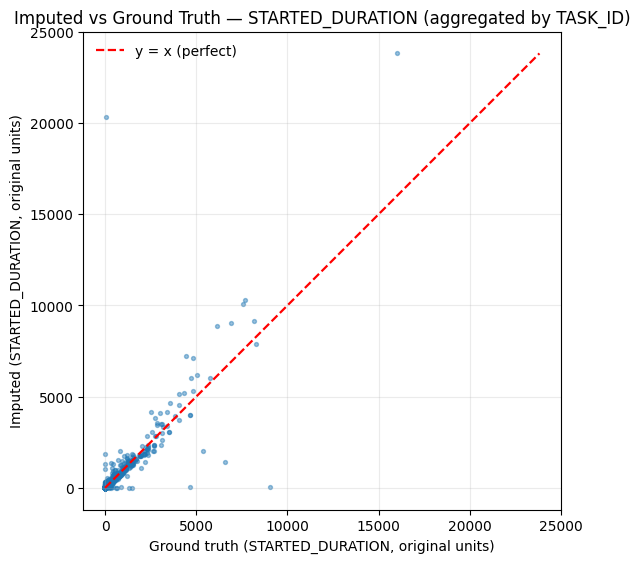

In [43]:
# ---- scatter (by TASK_ID) predictions vs ground truth in original units ----
import matplotlib.pyplot as plt

x = df["gt_original_units"].to_numpy()
y = df["pred_original_units"].to_numpy()

plt.figure(figsize=(6, 6))
plt.scatter(x, y, s=8, alpha=0.45, color="tab:blue")

lo = float(min(x.min(), y.min()))
hi = float(max(x.max(), y.max()))
plt.plot([lo, hi], [lo, hi], linestyle="--", color="red", linewidth=1.6, label="y = x (perfect)")

plt.xlabel(f"Ground truth ({target_feature}, original units)")
plt.ylabel(f"Imputed ({target_feature}, original units)")
plt.title(f"Imputed vs Ground Truth — {target_feature} (aggregated by TASK_ID)")
plt.gca().set_aspect("equal", "box")
plt.grid(True, alpha=0.25)
plt.legend(frameon=False, loc="best")
plt.tight_layout()
plt.show()


In [45]:
x = df["gt_original_units"].to_numpy(dtype=float)     # ground truth
y = df["pred_original_units"].to_numpy(dtype=float)   # predictions
err = y - x

MAE  = float(np.mean(np.abs(err)))
RMSE = float(np.sqrt(np.mean(err**2)))
MedE = float(np.median(np.abs(err)))
SS_res = float(np.sum(err**2))
SS_tot = float(np.sum((x - np.mean(x))**2))
R2   = float(1.0 - SS_res / SS_tot) if SS_tot > 0 else float("nan")

print(f"[{target_feature}] metrics on entries (by TASK_ID):")
print(f"  MAE : {MAE:.6f}")
print(f"  RMSE: {RMSE:.6f}")
print(f"  MedE: {MedE:.6f}")
print(f"  R^2 : {R2:.6f}")


[STARTED_DURATION] metrics on entries (by TASK_ID):
  MAE : 202.108584
  RMSE: 968.890327
  MedE: 37.557449
  R^2 : 0.442257


In [46]:
# Use X (ground-truth view) so SAITS sees more observed context.
dataset_for_IMPU_all_ctx = {"X": full_X.astype(np.float32)}
pred_all_ctx = saits.predict(dataset_for_IMPU_all_ctx)
imputation_all_ctx = pred_all_ctx["imputation"]  # shape: (N_all, T, D)
print("imputation_all_ctx:", imputation_all_ctx.shape)

imputation_all_ctx: (8930, 43, 20)


In [48]:
target_feature = "STARTED_DURATION"
target_idx = feature_columns.index(target_feature)

created_feature = "CREATED_DURATION"
created_idx     = feature_columns.index(created_feature)

# 1) mask: missing in X_hat AND not artificially-masked, for the target only
m_t = (full_missing_mask[..., target_idx+1] == 0) & \
      (full_indicating_mask[..., target_idx+1] == 0) & (full_padding_mask == 1) 
# 2) grab imputed target values at those positions (scaled/log space)
y_pred_s = imputation_all_ctx[..., target_idx+1][m_t].astype(float)

# 3) grab CREATED_DURATION at the same positions (scaled/log space)
created_s = full_X[..., created_idx+1][m_t].astype(float)

# 4) inverse STANDARDIZATION for TARGET
mu_t = float(scaler.mean_[target_idx])
sd_t = float(scaler.scale_[target_idx])
y_pred_lin = y_pred_s * sd_t + mu_t
# undo log1p for target if it was log-transformed
y_pred_lin = np.expm1(y_pred_lin)

# 5) inverse STANDARDIZATION for CREATED_DURATION
mu_c = float(scaler.mean_[created_idx])
sd_c = float(scaler.scale_[created_idx])
created_duration_lin = created_s * sd_c + mu_c
# undo log1p for created_duration if it was log-transformed
created_duration_lin = np.expm1(created_duration_lin)

print("Points (originally-missing target):", y_pred_lin.size)


Points (originally-missing target): 18297


In [49]:
task_ids.shape

(742,)

In [50]:
i, t = np.where(m_t)  # (N_idx, T_idx, D_idx); D_idx is the target column
task_ids = full_original_ids[i, t]

df = pd.DataFrame({
    "APPLICATION_TASK_ID": task_ids,
    "pred_original_units": y_pred_lin.astype(float),
    "created_duration": created_duration_lin.astype(float)
})

# save CSV next to outputs
if 'OUTPUT_DIR' in globals():
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    out_csv = os.path.join(OUTPUT_DIR, f"saits_imp_app_{target_feature}.csv")
    df.to_csv(out_csv, index=False)
    print("Saved:", out_csv)


Saved: pypots_outputs\saits_imp_app_STARTED_DURATION.csv


count    18297.000000
mean        60.678881
std        297.547386
min         -0.469536
10%          0.021840
25%          0.510948
50%          1.976615
75%         36.385384
90%        123.547772
max      13126.145445


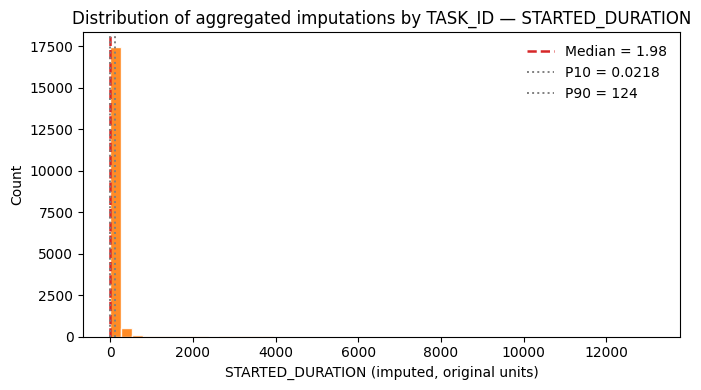

In [51]:
# ---- distribution of imputations, original units ----

vals = df["pred_original_units"].to_numpy(dtype=float)

# quick stats
stats = pd.Series(vals).describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
print(stats.to_string())

plt.figure(figsize=(7,4))
plt.hist(vals, bins=50, color="tab:orange", alpha=0.9, edgecolor="white")
med = float(np.median(vals))
p10, p90 = np.percentile(vals, [10, 90])

plt.axvline(med, color="tab:red",   linestyle="--", linewidth=1.8, label=f"Median = {med:.3g}")
plt.axvline(p10, color="tab:gray",  linestyle=":",  linewidth=1.4, label=f"P10 = {p10:.3g}")
plt.axvline(p90, color="tab:gray",  linestyle=":",  linewidth=1.4, label=f"P90 = {p90:.3g}")

plt.xlabel(f"{target_feature} (imputed, original units)")
plt.ylabel("Count")
plt.title(f"Distribution of aggregated imputations by TASK_ID — {target_feature}")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


In [52]:
total_all = len(df)

in_range = (df["pred_original_units"] > 0) & (df["pred_original_units"] < df["created_duration"])
in_range_valid = in_range.sum()

pct = (in_range_valid / total_all * 100.0) if total_all > 0 else float("nan")

print(f"Total imputations (all rows): {total_all}")
print(f"In range (0, created_duration): {in_range_valid} / {total_all}  ({pct:.2f}%)")

Total imputations (all rows): 18297
In range (0, created_duration): 16601 / 18297  (90.73%)


In [ ]:
### Runs for more than 2 hours ####

from pypots.imputation import BRITS
from pypots.nn.modules.loss import MAE

# initialize the model
brits = BRITS(
    n_steps=n_steps,
    n_features=n_features,
    rnn_hidden_size=512,
    batch_size=128,
    epochs=10000,
    patience=30,
    # give the optimizer.
    optimizer=Adam(lr=0.00015845087026482597),
    # Leaving it to default as 0 means data loading will be in the main process, i.e. there won't be subprocesses.
    num_workers=0,
    # just leave it to default as None, PyPOTS will automatically assign the best device for you.
    device=None,
    # set the path for saving tensorboard and trained model files
    saving_path=os.path.join(OUTPUT_DIR, "brits"),
    # only save the best model after training finished.
    model_saving_strategy="best",
    validation_metric=MAE
)

# train the model on the training set, and validate it on the validating set to select the best model for testing in the next step
brits.fit(
    train_set = dataset_for_IMPU_training,
    val_set = dataset_for_IMPU_validating,
)

# Test-time imputation
brits_pred = brits.predict(test_set=dataset_for_IMPU_testing)  # {"X": test_X_hat}
brits_imputation = brits_pred["imputation"]

# Evaluate only where ground truth exists but the missing view had NaN
mae = calc_mae(imputation, test_X_ori, test_indicating_mask)
print(f"Testing mean absolute error: {mae:.6f}")

2025-09-30 23:54:53 [INFO]: No given device, using default device: cuda
2025-09-30 23:54:53 [INFO]: Model files will be saved to pypots_outputs\saits\20250930_T235453
2025-09-30 23:54:53 [INFO]: Tensorboard file will be saved to pypots_outputs\saits\20250930_T235453\tensorboard
2025-09-30 23:54:53 [INFO]: Using customized MAE as the training loss function.
2025-09-30 23:54:53 [INFO]: Using customized MAE as the validation metric function.
2025-09-30 23:54:53 [INFO]: BRITS initialized with the given hyperparameters, the number of trainable parameters: 2,314,528
2025-09-30 23:55:17 [INFO]: Epoch 001 - training loss (MAE): 0.8578, validation MAE: 0.7764
2025-09-30 23:55:32 [INFO]: Epoch 002 - training loss (MAE): 0.8188, validation MAE: 0.7362
2025-09-30 23:55:47 [INFO]: Epoch 003 - training loss (MAE): 0.7488, validation MAE: 0.7144
2025-09-30 23:56:02 [INFO]: Epoch 004 - training loss (MAE): 0.7124, validation MAE: 0.7172
2025-09-30 23:56:20 [INFO]: Epoch 005 - training loss (MAE): 0.67

Testing mean absolute error: 0.218217


In [55]:
target_feature = "STARTED_DURATION" 
target_idx = feature_columns.index(target_feature)

# Keep only positions flagged by the indicator mask
m = test_indicating_mask.astype(bool)   # shape (N, T, D)

y_true = test_X_ori[m]      # ground truth values at those positions
y_pred = brits_imputation[m]      # model’s imputed values at those positions

# ---- inverse STANDARDIZATION for the target feature (IMPORTANT - only target feature is missing, change code logic if more features are masked)----
mu = float(scaler.mean_[target_idx])
sd = float(scaler.scale_[target_idx])
y_true_lin = y_true * sd + mu
y_pred_lin = y_pred * sd + mu

y_true_lin = np.expm1(y_true_lin)
y_pred_lin = np.expm1(y_pred_lin)


In [56]:
i, t, _ = np.where(m)  # (N_idx, T_idx, D_idx); D_idx is the target column
task_ids = test_original_ids[i, t]

df = pd.DataFrame({
    "APPLICATION_TASK_ID": task_ids,
    "gt_original_units":   y_true_lin.astype(float),
    "pred_original_units": y_pred_lin.astype(float),
})

mae_orig = float(np.mean(np.abs(df["pred_original_units"] - df["gt_original_units"])))
print(f"[{target_feature}] MAE (aggregated by TASK_ID, original units): {mae_orig:.6f}")
print("Unique tasks evaluated:", len(df))



[STARTED_DURATION] MAE (aggregated by TASK_ID, original units): 160.043701
Unique tasks evaluated: 742


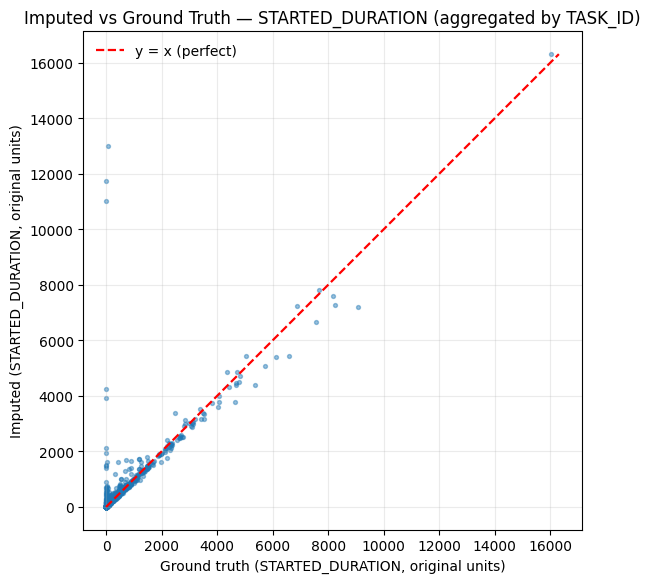

In [57]:
x = df["gt_original_units"].to_numpy()
y = df["pred_original_units"].to_numpy()

plt.figure(figsize=(6, 6))
plt.scatter(x, y, s=8, alpha=0.45, color="tab:blue")

lo = float(min(x.min(), y.min()))
hi = float(max(x.max(), y.max()))
plt.plot([lo, hi], [lo, hi], linestyle="--", color="red", linewidth=1.6, label="y = x (perfect)")

plt.xlabel(f"Ground truth ({target_feature}, original units)")
plt.ylabel(f"Imputed ({target_feature}, original units)")
plt.title(f"Imputed vs Ground Truth — {target_feature} (aggregated by TASK_ID)")
plt.gca().set_aspect("equal", "box")
plt.grid(True, alpha=0.25)
plt.legend(frameon=False, loc="best")
plt.tight_layout()
plt.show()


In [58]:
x = df["gt_original_units"].to_numpy(dtype=float)     # ground truth
y = df["pred_original_units"].to_numpy(dtype=float)   # predictions
err = y - x

MAE  = float(np.mean(np.abs(err)))
RMSE = float(np.sqrt(np.mean(err**2)))
MedE = float(np.median(np.abs(err)))
SS_res = float(np.sum(err**2))
SS_tot = float(np.sum((x - np.mean(x))**2))
R2   = float(1.0 - SS_res / SS_tot) if SS_tot > 0 else float("nan")

print(f"[{target_feature}] metrics on aggregated entries (by TASK_ID):")
print(f"  MAE : {MAE:.6f}")
print(f"  RMSE: {RMSE:.6f}")
print(f"  MedE: {MedE:.6f}")
print(f"  R^2 : {R2:.6f}")


[STARTED_DURATION] metrics on aggregated entries (by TASK_ID):
  MAE : 160.043701
  RMSE: 825.538336
  MedE: 21.297516
  R^2 : 0.595089


In [59]:
pred_all_ctx = brits.predict(dataset_for_IMPU_all_ctx)
imputation_all_ctx = pred_all_ctx["imputation"]
print("imputation_all_ctx:", imputation_all_ctx.shape)

imputation_all_ctx: (8930, 43, 20)


In [60]:
# 1) mask: missing in X_hat AND not artificially-masked, for the target only
m_t = (full_missing_mask[..., target_idx+1] == 0) & \
      (full_indicating_mask[..., target_idx+1] == 0) & (full_padding_mask == 1) 
# 2) grab imputed target values at those positions (scaled/log space)
y_pred_s = imputation_all_ctx[..., target_idx+1][m_t].astype(float)

# 3) grab CREATED_DURATION at the same positions (scaled/log space)
created_s = full_X[..., created_idx+1][m_t].astype(float)

# 4) inverse STANDARDIZATION for TARGET
mu_t = float(scaler.mean_[target_idx])
sd_t = float(scaler.scale_[target_idx])
y_pred_lin = y_pred_s * sd_t + mu_t
# undo log1p for target if it was log-transformed
y_pred_lin = np.expm1(y_pred_lin)

# 5) inverse STANDARDIZATION for CREATED_DURATION
mu_c = float(scaler.mean_[created_idx])
sd_c = float(scaler.scale_[created_idx])
created_duration_lin = created_s * sd_c + mu_c
# undo log1p for created_duration if it was log-transformed
created_duration_lin = np.expm1(created_duration_lin)

print("Points (originally-missing target):", y_pred_lin.size)


Points (originally-missing target): 18297


In [61]:
i, t = np.where(m_t)  # (N_idx, T_idx, D_idx); D_idx is the target column in your case
task_ids = full_original_ids[i, t]

df = pd.DataFrame({
    "APPLICATION_TASK_ID": task_ids,
    "pred_original_units": y_pred_lin.astype(float),
    "created_duration": created_duration_lin.astype(float)
})

# save CSV next to outputs
if 'OUTPUT_DIR' in globals():
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    out_csv = os.path.join(OUTPUT_DIR, f"brits_imputations_appl_{target_feature}.csv")
    df.to_csv(out_csv, index=False)
    print("Saved:", out_csv)


Saved: pypots_outputs\brits_imputations_appl_STARTED_DURATION.csv


count    18297.000000
mean        88.677239
std        370.563553
min         -0.132746
10%          0.020588
25%          0.460561
50%          2.611428
75%         48.386078
90%        199.063013
max      12699.477386


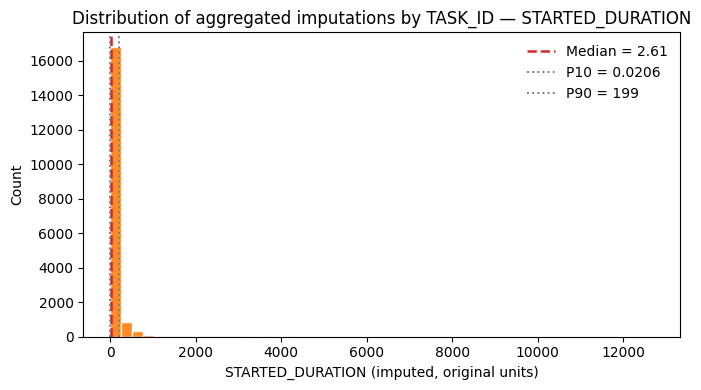

In [62]:
# ---- distribution of imputations (by TASK_ID), original units ----

vals = df["pred_original_units"].to_numpy(dtype=float)

# quick stats
stats = pd.Series(vals).describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
print(stats.to_string())

plt.figure(figsize=(7,4))
plt.hist(vals, bins=50, color="tab:orange", alpha=0.9, edgecolor="white")
med = float(np.median(vals))
p10, p90 = np.percentile(vals, [10, 90])

plt.axvline(med, color="tab:red",   linestyle="--", linewidth=1.8, label=f"Median = {med:.3g}")
plt.axvline(p10, color="tab:gray",  linestyle=":",  linewidth=1.4, label=f"P10 = {p10:.3g}")
plt.axvline(p90, color="tab:gray",  linestyle=":",  linewidth=1.4, label=f"P90 = {p90:.3g}")

plt.xlabel(f"{target_feature} (imputed, original units)")
plt.ylabel("Count")
plt.title(f"Distribution of aggregated imputations by TASK_ID — {target_feature}")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


In [63]:
total_all = len(df)

in_range = (df["pred_original_units"] > 0) & (df["pred_original_units"] < df["created_duration"])
in_range_valid = in_range.sum()

pct = (in_range_valid / total_all * 100.0) if total_all > 0 else float("nan")

print(f"Total aggregated imputations (all rows): {total_all}")
print(f"In range (0, created_duration): {in_range_valid} / {total_all}  ({pct:.2f}%)")

Total aggregated imputations (all rows): 18297
In range (0, created_duration): 17018 / 18297  (93.01%)


In [64]:
N_DATASETS   = 2    # number of MICE completed datasets
N_ITER       = 5     # MICE iterations
RANDOM_SEED  = 0

# === imports ===
import os, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import miceforest as mf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
os.makedirs(OUTPUT_DIR, exist_ok=True)
np.set_printoptions(suppress=True)

In [65]:
to_impute = (
    df_before_scaling
    .drop(columns=["STARTED_DURATION_ground"], errors="ignore")
    .reset_index(drop=True)
    .copy()
)

to_impute

,REVISION_NUMBER,TASK_ITERATION,USER_TASK_STATUS,FIRST_ASSIGN_DURATION,CREATED_DURATION,STARTED_DURATION,TASK_HISTORY_STATUS_CHANGES,HALT_DURATION,APPLICATION_DURATION,HIGH_RISK_IND,MAJOR_PROJECT_IND,OPEN_APPLICATIONS,OPEN_TASKS,PRIORITY_CODE,TOTAL_ACTIVITY_COUNT,WAITING_TIME,TASK_COUNT,CREATED_DATE_hours,LATEST_DATE_hours,APPLICATION_STATUS_CODE2
0,0,0,0,4.566667,26.466667,4.553056,4,0.0,46.454861,0,0,0,0,0,1,1.000000,5,274.500000,300.966667,1
1,0,0,0,72.250000,72.650000,72.243333,4,0.0,46.454861,0,0,0,0,0,1,1.000000,5,298.566667,371.216667,1
2,0,0,0,845.683333,964.516667,387.646944,6,0.0,46.454861,0,0,0,0,0,1,1.000000,5,274.500000,1239.016667,1
3,0,0,0,1.233333,1.666667,1.213611,4,0.0,46.454861,0,0,0,44,0,1,1.000000,5,1239.016667,1240.683333,1
4,0,0,0,0.050000,90.233333,0.034722,4,0.0,46.454861,0,0,0,0,0,1,1.000000,5,1240.683333,1330.916667,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73068,2,2,0,0.116667,0.350000,0.009444,4,0.0,2.303368,1,1,17,1,1,27,67.939213,7,71407.933333,71408.283333,1
73069,2,2,0,49.250000,52.000000,NaN,5,0.0,2.303368,1,1,17,0,1,27,67.939213,7,71407.933333,71459.933333,1
73070,2,2,0,49.633333,52.383333,NaN,5,0.0,2.303368,1,1,17,1,1,27,67.939213,7,71407.933333,71460.316667,1
73071,2,0,0,2.416667,2.416667,2.403611,4,0.0,2.303368,1,1,17,0,1,27,67.939213,7,71460.316667,71462.733333,1


In [66]:
# Build and run the kernel
kernel = mf.ImputationKernel(
    to_impute,
    num_datasets=N_DATASETS,
    random_state=RANDOM_SEED,
)
kernel.mice(N_ITER, verbose=True)

# Take the mean across completed datasets for stability
completed = [kernel.complete_data(i) for i in range(N_DATASETS)]
imputed_data = pd.concat(completed).groupby(level=0).mean(numeric_only=True)

print("Imputed dataframe shape:", imputed_data.shape)
imputed_data.head()


Initialized logger with name MICE Iterations 1 - 5 and 4 levels
1 Dataset 0
 | STARTED_DURATION
Dataset 1
 | STARTED_DURATION
2 Dataset 0
 | STARTED_DURATION
Dataset 1
 | STARTED_DURATION
3 Dataset 0
 | STARTED_DURATION
Dataset 1
 | STARTED_DURATION
4 Dataset 0
 | STARTED_DURATION
Dataset 1
 | STARTED_DURATION
5 Dataset 0
 | STARTED_DURATION
Dataset 1
 | STARTED_DURATION
Imputed dataframe shape: (73073, 20)


,REVISION_NUMBER,TASK_ITERATION,USER_TASK_STATUS,FIRST_ASSIGN_DURATION,CREATED_DURATION,STARTED_DURATION,TASK_HISTORY_STATUS_CHANGES,HALT_DURATION,APPLICATION_DURATION,HIGH_RISK_IND,MAJOR_PROJECT_IND,OPEN_APPLICATIONS,OPEN_TASKS,PRIORITY_CODE,TOTAL_ACTIVITY_COUNT,WAITING_TIME,TASK_COUNT,CREATED_DATE_hours,LATEST_DATE_hours,APPLICATION_STATUS_CODE2
0,0.0,0.0,0.0,4.566667,26.466667,4.553056,4.0,0.0,46.454861,0.0,0.0,0.0,0.0,0.0,1.0,1.0,5.0,274.500000,300.966667,1.0
1,0.0,0.0,0.0,72.250000,72.650000,72.243333,4.0,0.0,46.454861,0.0,0.0,0.0,0.0,0.0,1.0,1.0,5.0,298.566667,371.216667,1.0
2,0.0,0.0,0.0,845.683333,964.516667,387.646944,6.0,0.0,46.454861,0.0,0.0,0.0,0.0,0.0,1.0,1.0,5.0,274.500000,1239.016667,1.0
3,0.0,0.0,0.0,1.233333,1.666667,1.213611,4.0,0.0,46.454861,0.0,0.0,0.0,44.0,0.0,1.0,1.0,5.0,1239.016667,1240.683333,1.0
4,0.0,0.0,0.0,0.050000,90.233333,0.034722,4.0,0.0,46.454861,0.0,0.0,0.0,0.0,0.0,1.0,1.0,5.0,1240.683333,1330.916667,1.0


In [67]:
df_eval = df_before_scaling.reset_index(drop=False)   # same row order/length as `to_impute` and `imputed_data`

# missing in `STARTED_DURATION` but GT exists
art_mask_np = (
    df_eval["STARTED_DURATION"].isna().to_numpy() &
    df_eval["STARTED_DURATION_ground"].notna().to_numpy()
)

In [68]:
# pull arrays positionally
imp = imputed_data["STARTED_DURATION"].to_numpy()[art_mask_np]
gt  = df_eval["STARTED_DURATION_ground"].to_numpy()[art_mask_np]

# Metrics
MAE  = float(mean_absolute_error(gt, imp))
RMSE = float(np.sqrt(mean_squared_error(gt, imp)))
MdAE = float(np.median(np.abs(imp - gt)))

R2   = float(r2_score(gt, imp)) if np.var(gt) > 0 else float("nan")

print("=== MICE metrics (artificially-masked) ===")
print(f"MAE : {MAE:.6f}")
print(f"RMSE: {RMSE:.6f}")
print(f"MdAE: {MdAE:.6f}")
print(f"R^2 : {R2:.6f}")

=== MICE metrics (artificially-masked) ===
MAE : 149.816016
RMSE: 517.422894
MdAE: 29.080694
R^2 : 0.924595


In [69]:
test_task_ids = np.unique(test_original_ids)
test_task_ids = test_task_ids[test_task_ids != -1].astype(int)
print("Unique test tasks (SAITS/BRITS):", test_task_ids.size)

Unique test tasks (SAITS/BRITS): 7507


In [ ]:
# Map each row to its APPLICATION_TASK_ID (aligned with imputed_data)
if isinstance(df_before_scaling.index, pd.MultiIndex):
    app_task_ids = df_before_scaling.index.get_level_values('APPLICATION_TASK_ID').to_numpy()
else:
    app_task_ids = df_before_scaling['APPLICATION_TASK_ID'].to_numpy()

# Build an eval frame in ORIGINAL units (no scaling/log for MICE)
df_eval = pd.DataFrame({
    "APPLICATION_TASK_ID": app_task_ids,
    "STARTED_DURATION":    imputed_data["STARTED_DURATION"].to_numpy(),        # MICE imputations
    "STARTED_DURATION_ground": df_before_scaling["STARTED_DURATION_ground"].to_numpy(),  # GT
})

# Artificially-masked rows (missing in the missing file, GT exists) — aligned with df_before_scaling/imputed_data
art_mask_np = (
    df_before_scaling["STARTED_DURATION"].isna().to_numpy() &
    df_before_scaling["STARTED_DURATION_ground"].notna().to_numpy()
)

# Restrict to the same TASK IDs as SAITS/BRITS test
is_test = np.isin(df_eval["APPLICATION_TASK_ID"].astype(int).to_numpy(),
                  test_task_ids)

mask = is_test & art_mask_np
print("Rows selected (MICE, same tasks as SAITS/BRITS, artificially-masked only):", int(mask.sum()))

Rows selected (MICE, same tasks as SAITS/BRITS, artificially-masked only): 742


In [71]:
imp = df_eval.loc[mask, "STARTED_DURATION"].to_numpy()
gt  = df_eval.loc[mask, "STARTED_DURATION_ground"].to_numpy()

# Metrics (original units)
MAE  = float(mean_absolute_error(gt, imp))
RMSE = float(np.sqrt(mean_squared_error(gt, imp)))
MdAE = float(np.median(np.abs(imp - gt)))

SS_res = float(np.sum((imp - gt)**2))
SS_tot = float(np.sum((gt - gt.mean())**2))
R2     = float(1.0 - SS_res / SS_tot) if SS_tot > 0 else float("nan")

n_tasks = int(pd.Series(df_eval.loc[mask, "APPLICATION_TASK_ID"]).nunique())
print(f"MICE on SAITS/BRITS test tasks: rows={int(mask.sum())}, tasks={n_tasks}")
print(f"  MAE : {MAE:.6f}")
print(f"  RMSE: {RMSE:.6f}")
print(f"  MdAE: {MdAE:.6f}")
print(f"  R^2 : {R2:.6f}")


MICE on SAITS/BRITS test tasks: rows=742, tasks=742
  MAE : 152.666943
  RMSE: 731.549871
  MdAE: 25.753264
  R^2 : 0.682039


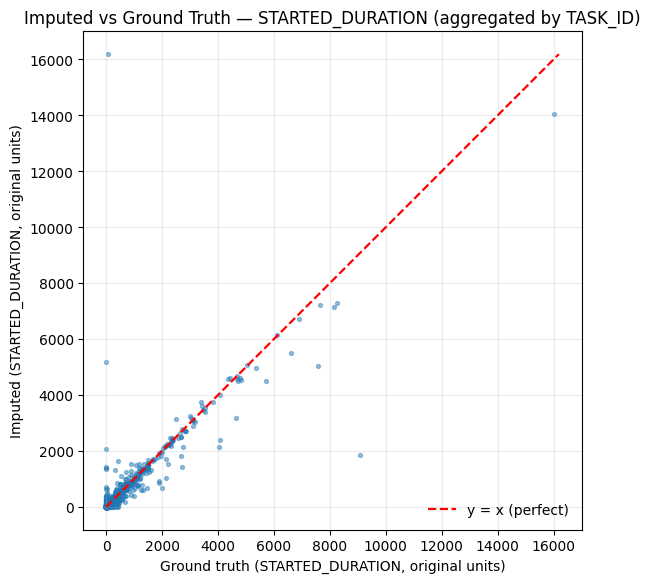

In [72]:
plt.figure(figsize=(6, 6))
plt.scatter(gt, imp, s=8, alpha=0.45, color="tab:blue")

lo = float(min(imp.min(), gt.min()))
hi = float(max(imp.max(), gt.max()))
plt.plot([lo, hi], [lo, hi], linestyle="--", color="red", linewidth=1.6, label="y = x (perfect)")

plt.xlabel(f"Ground truth ({target_feature}, original units)")
plt.ylabel(f"Imputed ({target_feature}, original units)")
plt.title(f"Imputed vs Ground Truth — {target_feature} (aggregated by TASK_ID)")
plt.gca().set_aspect("equal", "box")
plt.grid(True, alpha=0.25)
plt.legend(frameon=False, loc="best")
plt.tight_layout()
plt.show()
